### Import Modules

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
LATENT_DIM = 32
HIDDEN_DIM = 512
EPOCHS = 50
BATCH_SIZE = 128
LR = 1e-3
INPUT_DIM = 784
NUM_CLASSES = 10
BETA = 1.0

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

### Helper Functions

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    recon = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + BETA * kl

In [ ]:
def one_hot(labels):
    return torch.zeros(labels.size(0), NUM_CLASSES).to(labels.device).scatter_(
        1, labels.unsqueeze(1), 1
    )

In [ ]:
def plot_loss(losses, label='Model'):
    plt.figure(figsize=(7, 4))
    plt.plot(losses, label=label)
    plt.xlabel('Epoch')
    plt.ylabel('Avg Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig("loss_curve.png")
    plt.show()

In [ ]:
def generate_vae_samples(model, n=10):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, LATENT_DIM).to(device)
        imgs = model.decode(z).cpu().view(n, 28, 28)
    fig, axes = plt.subplots(1, n, figsize=(n, 1.5))
    for ax, img in zip(axes, imgs):
        ax.imshow(img, cmap='gray'); ax.axis('off')
    plt.suptitle("VAE — random samples", y=1.02)
    plt.tight_layout(); plt.savefig("vae_samples.png", bbox_inches='tight'); plt.show()

In [ ]:
def generate_cvae_samples(model):
    model.eval()
    with torch.no_grad():
        labels = torch.arange(NUM_CLASSES).to(device)
        c = one_hot(labels)
        z = torch.randn(NUM_CLASSES, LATENT_DIM).to(device)
        imgs = model.decode(z, c).cpu().view(NUM_CLASSES, 28, 28)
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES, 1.5))
    for ax, img, d in zip(axes, imgs, range(NUM_CLASSES)):
        ax.imshow(img, cmap='gray'); ax.set_title(str(d), fontsize=8); ax.axis('off')
    plt.suptitle("CVAE — one sample per digit", y=1.05)
    plt.tight_layout(); plt.savefig("cvae_samples.png", bbox_inches='tight'); plt.show()

### Part 1: VAE

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_hidden = nn.Sequential(nn.Linear(INPUT_DIM, HIDDEN_DIM), nn.ReLU())
        self.fc_mu     = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.fc_logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)

        self.dec_hidden = nn.Sequential(nn.Linear(LATENT_DIM, HIDDEN_DIM), nn.ReLU())
        self.dec_out    = nn.Sequential(nn.Linear(HIDDEN_DIM, INPUT_DIM), nn.Sigmoid())

    def encode(self, x):
        h = self.enc_hidden(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + torch.exp(0.5 * logvar) * eps

    def decode(self, z):
        return self.dec_out(self.dec_hidden(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
vae = VAE().to(device)

In [ ]:
optimizer = optim.Adam(vae.parameters(), lr=LR)

losses = []
for epoch in range(1, EPOCHS + 1):
    vae.train()
    total = 0

    for x, _ in train_loader:
        x = x.view(-1, INPUT_DIM).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total += loss.item()

    avg = total / len(train_data)
    losses.append(avg)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{EPOCHS}  Loss: {avg:.2f}")

Epoch 10/50  Loss: 105.56
Epoch 20/50  Loss: 103.43
Epoch 30/50  Loss: 102.43
Epoch 40/50  Loss: 101.77
Epoch 50/50  Loss: 101.28


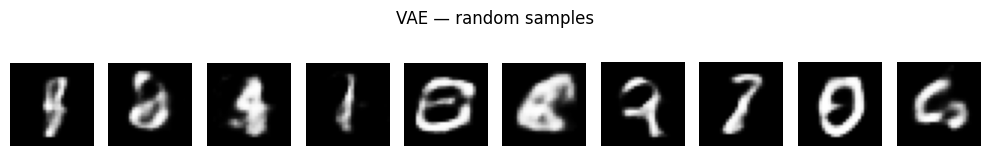

In [ ]:
generate_vae_samples(vae)

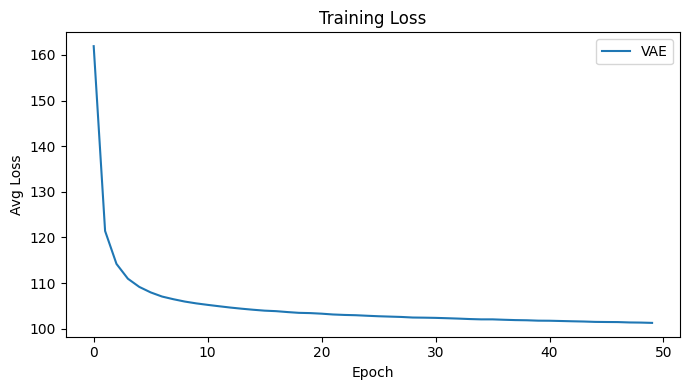

In [ ]:
plot_loss(losses, label='VAE')

### Part 2: CVAE


In [ ]:
class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_hidden = nn.Sequential(
            nn.Linear(INPUT_DIM + NUM_CLASSES, HIDDEN_DIM), nn.ReLU()
        )
        self.fc_mu     = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.fc_logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)

        self.dec_hidden = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_CLASSES, HIDDEN_DIM), nn.ReLU()
        )
        self.dec_out = nn.Sequential(nn.Linear(HIDDEN_DIM, INPUT_DIM), nn.Sigmoid())

    def encode(self, x, c):
        h = self.enc_hidden(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + torch.exp(0.5 * logvar) * eps

    def decode(self, z, c):
        return self.dec_out(self.dec_hidden(torch.cat([z, c], dim=1)))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

In [ ]:
cvae = CVAE().to(device)

In [ ]:
optimizer = optim.Adam(cvae.parameters(), lr=LR)

losses = []
for epoch in range(1, EPOCHS + 1):
    cvae.train()
    total = 0

    for x, y in train_loader:
        x = x.view(-1, INPUT_DIM).to(device)
        y = one_hot(y.to(device))

        optimizer.zero_grad()

        recon, mu, logvar = cvae(x, y)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total += loss.item()

    avg = total / len(train_data)
    losses.append(avg)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{EPOCHS}  Loss: {avg:.2f}")

Epoch 10/50  Loss: 101.63
Epoch 20/50  Loss: 99.00
Epoch 30/50  Loss: 97.78
Epoch 40/50  Loss: 97.05
Epoch 50/50  Loss: 96.48


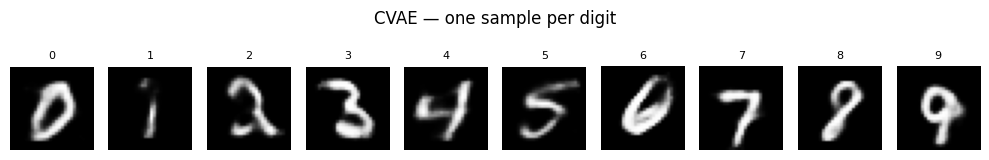

In [ ]:
generate_cvae_samples(cvae)

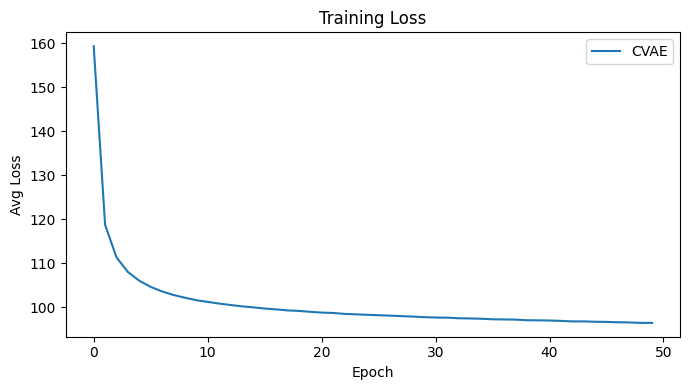

In [ ]:
plot_loss(losses, label='CVAE')